 
# Theory

### Wolff Cluster Alogrithm
1. Randomly choose a site, the speed spin
2. If a neighbouring spin is pointing in the same direction as the speed spin, add them to our cluster $\mathfrak{C}$ with probability $P_\text{add}=1-e^{-2\beta J}$ 
3. In each we added repeat step 2, until there are no neighbouring spins left to be considered for inclusion in $\mathfrak{C}$ 
4. Flip the Cluster $\mathfrak{C}$

# Implementation

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from numba import njit

### Ising energy

In [2]:
def energy(s, J, h):
    #2D Ising energy with periodic boundary conditions.
    
    E = 0.0
    N = s.shape[0]

    for i in range(N):
        for j in range(N):
            E -= J * s[i, j] * (
                s[(i + 1) % N, j] +
                s[i, (j + 1) % N]
            )
            E -= h * s[i, j]

    return E

@njit
def sweep_once(s, N, J, h, T, E):
    for _ in range(N * N):
        x = np.random.randint(N)
        y = np.random.randint(N)

        nn = (
            s[(x + 1) % N, y] +
            s[(x - 1) % N, y] +
            s[x, (y + 1) % N] +
            s[x, (y - 1) % N]
        )

        dE = 2 * s[x, y] * (J * nn + h)

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[x, y] *= -1
            E += dE

    return E

### Wolff

In [3]:
def simulate_wolff(L, beta, num_steps=1000):
    spins = np.random.choice([-1,1], size=(L,L))
    for _ in range(num_steps):
        wolff_step(spins, beta)
    return spins

def wolff_step(spins,beta, record_history=False):
    J=1
    Lx,Ly = spins.shape
    checked = np.zeros((Lx, Ly), dtype=bool)
    
    # (step 1) random seed spin
    x0 = np.random.randint(0, Lx)
    y0 = np.random.randint(0, Ly)
    seed_spin = spins[x0, y0]
    cluster = [(x0, y0)]
    checked[x0, y0] = True
    
    # probability add
    Padd= 1 - np.exp(-2*beta*J)
    
    history = []                      # list to hold snapshots
    if record_history:
        history.append(checked.copy())   # capture initial state (just the seed)

    
    # (step 2) build the cluster
    while cluster: # equiv to while len(cluster)>0
        i, j = cluster.pop() 
        ''' pop takes the last elemnet out of cluster (the seed spin)
            and returns its coordinates (i,j)
        '''
        for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
            ni, nj = (i + di)% Lx, (j + dj)% Ly
        
            if not checked[ni, nj] and spins[ni, nj] == seed_spin: # and check new state matched seed 
                if np.random.rand() < Padd:
                    cluster.append((ni,nj))
                    checked[ni,nj]= True
        if record_history:
            history.append(checked.copy())
   
   # (step 3) flip the cluster 
    for i, j in np.argwhere(checked):
        spins[i,j]*= -1 # flip spin in cluster
    
    '''   equivalent
    for i in range(Lx):
        for j in range(Ly):
            if checked[i,j]:
                spins[i,j]*= -1
    '''     
    if record_history:
        return spins, history
    return spins
    

#### wolff with njit 
We need to simplify the syntax for njit to work

In [4]:
@njit
def wolff_step_numba(spins, beta):
    J = 1.0
    Lx, Ly = spins.shape
    checked = np.zeros((Lx, Ly), dtype=np.bool_)

    i0 = np.random.randint(0, Lx)
    j0 = np.random.randint(0, Ly)
    seed_spin = spins[i0, j0]

    # manual stack using preallocated arrays (max possible size = Lx*Ly)
    stack_i = np.empty(Lx * Ly, dtype=np.int64)
    stack_j = np.empty(Lx * Ly, dtype=np.int64)
    stack_i[0] = i0
    stack_j[0] = j0
    stack_size = 1
    checked[i0, j0] = True

    p_add = 1 - np.exp(-2 * beta * J)

    di_list = np.array([-1, 1, 0, 0])
    dj_list = np.array([0, 0, -1, 1])

    while stack_size > 0:
        stack_size -= 1
        i = stack_i[stack_size]
        j = stack_j[stack_size]

        for k in range(4):
            ni = (i + di_list[k]) % Lx
            nj = (j + dj_list[k]) % Ly
            if not checked[ni, nj] and spins[ni, nj] == seed_spin:
                if np.random.random() < p_add:
                    checked[ni, nj] = True
                    stack_i[stack_size] = ni
                    stack_j[stack_size] = nj
                    stack_size += 1

    for i in range(Lx):
        for j in range(Ly):
            if checked[i, j]:
                spins[i, j] *= -1

    return spins


@njit
def simulate_wolff_numba(L, beta, num_steps=1000):
    spins = np.random.choice(np.array([-1, 1]), size=(L, L)).astype(np.float64)
    for _ in range(num_steps):
        wolff_step_numba(spins, beta)
    return spins

### Animations 
we want to show cluster growth around $T_c$

In [5]:
Tc = 2.26918531421
betac= 1/Tc
print(betac)

0.4406867935103584


#### cluster growth

In [ ]:
L=100
beta=0.7


spins = np.random.choice(np.array([-1, 1]), size=(L, L)).astype(np.float64)
for _ in range(1000):
    wolff_step_numba(spins, beta)
    
print("equilibrated")
_, history = wolff_step(spins, beta, record_history=True)
print("history")

fig, ax = plt.subplots()
im = ax.imshow(history[0], cmap="gray", vmin=0, vmax=1)
ax.axis("off")

def update(frame):
    im.set_data(history[frame])
    ax.set_title(rf"Cluster growth: step {frame}/{len(history)-1} with $\beta=${beta}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(history), interval=100, blit=False)
ani.save(f"plots_wolff_cluster_growth/wolff_cluster_growth_{L}x{L}_and_beta{beta}.gif", writer="pillow", fps=10)
plt.close(fig)

equilibrated
history


We see at $0.50\approx\beta>\beta_c\approx 0.44$ which means $T<T_c$ and we have a well ordered state and clusters can contain the majority if not all states.

Whereas, $0.40\approx\beta<\beta_c\approx 0.44$ which means $T>T_c$, we have disordered states and clusters form pockects in the lattice.


#### full animation


In [ ]:
def make_frame(spins, checked):
    """
    spins: 2D array of +1/-1
    checked: 2D boolean array (True = part of cluster so far)
    Returns an (Lx, Ly, 3) RGB image:
        spin == +1  -> light gray
        spin == -1  -> black
        checked     -> white (overrides spin color)
    """
    Lx, Ly = spins.shape
    img = np.zeros((Lx, Ly, 3))  # start black

    # spin == +1 -> gray
    img[spins == 1] = [0.7, 0.7, 0.7]
    # spin == -1 -> black (already default, but explicit for clarity)
    img[spins == -1] = [0.0, 0.0, 0.0]

    # cluster sites -> purle, overriding whatever was set above
    img[checked] = [0.65, 0.0, 1.0]

    return img

In [7]:
def wolff_step_with_history(spins, beta):
    J = 1.0
    Lx, Ly = spins.shape
    checked = np.zeros((Lx, Ly), dtype=bool)

    i0 = np.random.randint(0, Lx)
    j0 = np.random.randint(0, Ly)
    seed_spin = spins[i0, j0]
    cluster = [(i0, j0)]
    checked[i0, j0] = True

    p_add = 1 - np.exp(-2 * beta * J)

    history = [make_frame(spins, checked)]   # <-- composite frame, not just checked

    while cluster:
        i, j = cluster.pop()
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            ni = (i + di) % Lx
            nj = (j + dj) % Ly
            if not checked[ni, nj] and spins[ni, nj] == seed_spin:
                if np.random.random() < p_add:
                    checked[ni, nj] = True
                    cluster.append((ni, nj))
        history.append(make_frame(spins, checked))   # <-- composite frame each step

    for i, j in np.argwhere(checked):
        spins[i, j] *= -1

    return spins, history

In [12]:
L=10
beta=0.5

spins = np.random.choice(np.array([-1, 1]), size=(L, L)).astype(np.float64)
for _ in range(200):
    wolff_step_numba(spins, beta)
    
print("equilibrated")
_, history = wolff_step_with_history(spins, beta)
print("history")

equilibrated
history


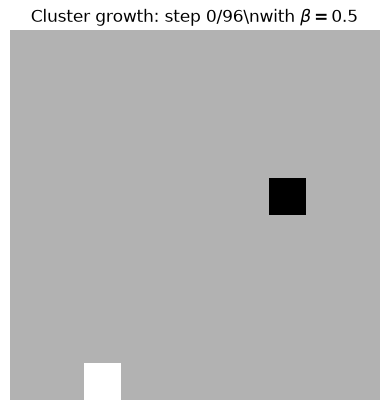

In [13]:
fig, ax = plt.subplots()
im = ax.imshow(history[0])   # no cmap needed — already RGB
ax.axis("off")

def update(frame):
    im.set_data(history[frame])
    ax.set_title(rf"Cluster growth: step {frame}/{len(history)-1}\nwith $\beta=${beta}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(history), interval=100, blit=False)
ani.save(f"wolff_cluster_growth_{L}x{L}.gif", writer="pillow", fps=10)